# CH 6 : Factor 4 - Presence of Positive Outliers in Rule Returns

## Objectif pédagogique

Ce notebook transforme le concept EBTA des **outliers positifs** en simulations Python concrètes.

L'objectif est de montrer pourquoi une stratégie sans vrai pouvoir prédictif peut apparaître comme excellente en **backtest**, simplement parce qu'elle a capturé quelques observations extrêmes.

> **Idée centrale :** le minage de données ne cherche pas la vérité. Il cherche le meilleur score observé. Dans un marché à **queues épaisses**, ce meilleur score peut être un accident statistique.

## 1. Le problème EBTA

Dans un backtest, la performance observée peut être décomposée ainsi :

$$
P_{\text{obs}} = P_{\text{pred}} + H
$$

Avec :

| Terme | Signification |
|---|---|
| $P_{\text{obs}}$ | Performance observée dans le backtest |
| $P_{\text{pred}}$ | Pouvoir prédictif réel de la règle |
| $H$ | Hasard, bruit, chance ou malchance |

Dans le cas dangereux étudié ici, la règle n'a pas de mérite réel :

$$
P_{\text{pred}} = 0
$$

Mais elle peut quand même afficher une performance élevée si :

$$
H \gg 0
$$

Ce phénomène est amplifié quand l'historique contient des **outliers positifs**.

## 2. Intuition simple : un seul gros mois peut gonfler la moyenne

Supposons une règle médiocre avec 24 mois de rendements proches de zéro.

Puis, par hasard, elle capture un mois extrême à $+20\%$.

La moyenne devient artificiellement élevée :

$$
\bar{r} = \frac{1}{N}\sum_{i=1}^{N} r_i
$$

L'impact d'un outlier positif isolé est approximativement :

$$
\Delta \bar{r} = \frac{\text{outlier}}{N}
$$

Donc plus $N$ est petit, plus l'outlier domine la conclusion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Petit échantillon : 24 mois
n = 24

# Rendements mensuels d'une règle sans edge réel
returns_without_outlier = np.random.normal(loc=0.0, scale=0.02, size=n)

# Même série, mais avec un outlier positif de +20 %
returns_with_outlier = returns_without_outlier.copy()
returns_with_outlier[5] = 0.20

summary = pd.DataFrame({
    "Cas": ["Sans outlier", "Avec outlier +20%"],
    "Moyenne mensuelle": [returns_without_outlier.mean(), returns_with_outlier.mean()],
    "Performance cumulée": [(1 + returns_without_outlier).prod() - 1,
                            (1 + returns_with_outlier).prod() - 1],
    "Meilleur mois": [returns_without_outlier.max(), returns_with_outlier.max()]
})

summary

,Cas,Moyenne mensuelle,Performance cumulée,Meilleur mois
0,Sans outlier,-0.002953,-0.072588,0.031584
1,Avec outlier +20%,0.005576,0.118130,0.200000


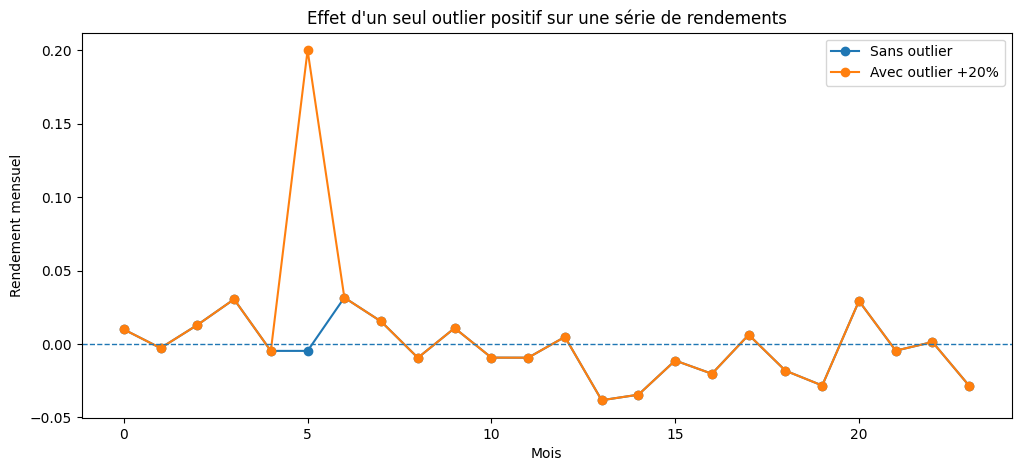

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(returns_without_outlier, marker="o", label="Sans outlier")
plt.plot(returns_with_outlier, marker="o", label="Avec outlier +20%")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Effet d'un seul outlier positif sur une série de rendements")
plt.xlabel("Mois")
plt.ylabel("Rendement mensuel")
plt.legend()
plt.show()

## 3. Light tails vs heavy tails

Une distribution à **queues légères** produit rarement des extrêmes.

Une distribution à **queues épaisses** produit plus souvent des observations très éloignées de la moyenne.

Dans les marchés financiers, les rendements sont souvent plus proches d'une logique à **queues épaisses** qu'une belle distribution normale idéale.

| Type de distribution | Comportement | Danger EBTA |
|---|---|---|
| **Light tails** | Les extrêmes sont rares | Moins de faux gagnants |
| **Heavy tails** | Les extrêmes sont plus fréquents | Plus de faux gagnants |

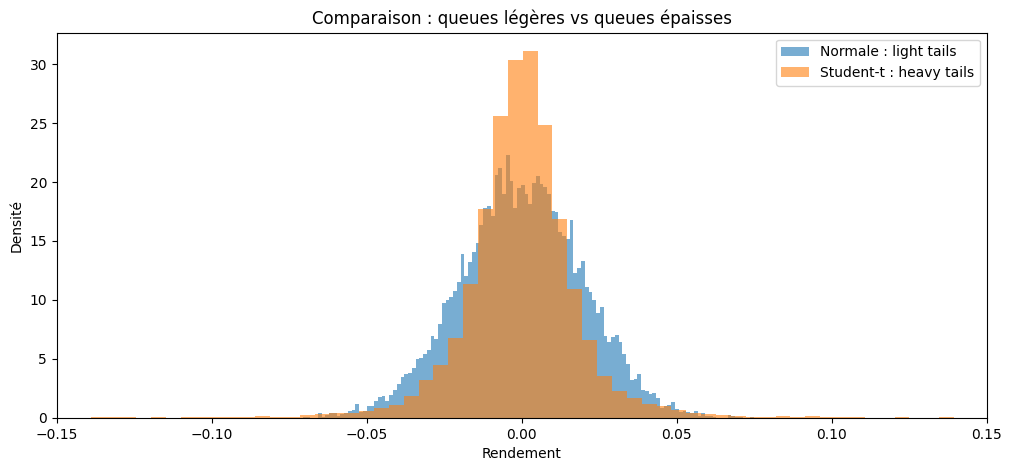

,Distribution,P(r > +5%),P(r > +10%),Maximum observé
0,Normale,0.0057,0.0000,0.074858
1,Student-t heavy tails,0.0113,0.0014,0.230539


In [3]:
np.random.seed(7)

n_obs = 10_000

# Distribution normale : queues plus légères
normal_returns = np.random.normal(loc=0, scale=0.02, size=n_obs)

# Distribution Student-t : queues épaisses
# On scale pour obtenir une volatilité comparable
heavy_tail_returns = np.random.standard_t(df=3, size=n_obs) * 0.02 / np.sqrt(3)

plt.figure(figsize=(12, 5))
plt.hist(normal_returns, bins=120, alpha=0.6, density=True, label="Normale : light tails")
plt.hist(heavy_tail_returns, bins=120, alpha=0.6, density=True, label="Student-t : heavy tails")
plt.xlim(-0.15, 0.15)
plt.title("Comparaison : queues légères vs queues épaisses")
plt.xlabel("Rendement")
plt.ylabel("Densité")
plt.legend()
plt.show()

tail_stats = pd.DataFrame({
    "Distribution": ["Normale", "Student-t heavy tails"],
    "P(r > +5%)": [(normal_returns > 0.05).mean(), (heavy_tail_returns > 0.05).mean()],
    "P(r > +10%)": [(normal_returns > 0.10).mean(), (heavy_tail_returns > 0.10).mean()],
    "Maximum observé": [normal_returns.max(), heavy_tail_returns.max()]
})

tail_stats

## 4. Simulation EBTA : minage de données sur règles sans edge

Nous allons simuler une compétition de backtest.

Chaque règle n'a aucun edge réel :

$$
E[r] = 0
$$

Mais on teste beaucoup de règles candidates.

Ensuite, on sélectionne la meilleure.

C'est exactement la logique dangereuse du **data mining** :

$$
\max(\bar{r}_1, \bar{r}_2, ..., \bar{r}_M)
$$

Même si toutes les règles sont nulles, la meilleure moyenne observée peut être élevée par hasard.

In [4]:
def simulate_data_mining(
    n_rules=1000,
    n_obs=60,
    distribution="normal",
    seed=123
):
    """
    Simule un concours de backtest entre règles sans edge réel.

    Chaque règle a une espérance nulle.
    On sélectionne ensuite la règle avec la meilleure moyenne observée.
    """
    rng = np.random.default_rng(seed)

    if distribution == "normal":
        returns = rng.normal(loc=0, scale=0.02, size=(n_rules, n_obs))
    elif distribution == "heavy_tail":
        # Student-t à queues épaisses, scalée pour rester comparable
        returns = rng.standard_t(df=3, size=(n_rules, n_obs)) * 0.02 / np.sqrt(3)
    else:
        raise ValueError("distribution doit être 'normal' ou 'heavy_tail'")

    mean_returns = returns.mean(axis=1)
    best_idx = np.argmax(mean_returns)

    return {
        "returns": returns,
        "mean_returns": mean_returns,
        "best_idx": best_idx,
        "best_mean": mean_returns[best_idx],
        "best_returns": returns[best_idx]
    }


normal_mining = simulate_data_mining(distribution="normal")
heavy_mining = simulate_data_mining(distribution="heavy_tail")

pd.DataFrame({
    "Distribution": ["Normale", "Heavy tails"],
    "Meilleure moyenne mensuelle observée": [normal_mining["best_mean"], heavy_mining["best_mean"]],
    "Meilleur rendement mensuel dans la règle gagnante": [
        normal_mining["best_returns"].max(),
        heavy_mining["best_returns"].max()
    ],
    "Performance cumulée de la règle gagnante": [
        (1 + normal_mining["best_returns"]).prod() - 1,
        (1 + heavy_mining["best_returns"]).prod() - 1
    ]
})

,Distribution,Meilleure moyenne mensuelle observée,Meilleur rendement mensuel dans la règle gagnante,Performance cumulée de la règle gagnante
0,Normale,0.007839,0.062253,0.583143
1,Heavy tails,0.009225,0.236906,0.681408


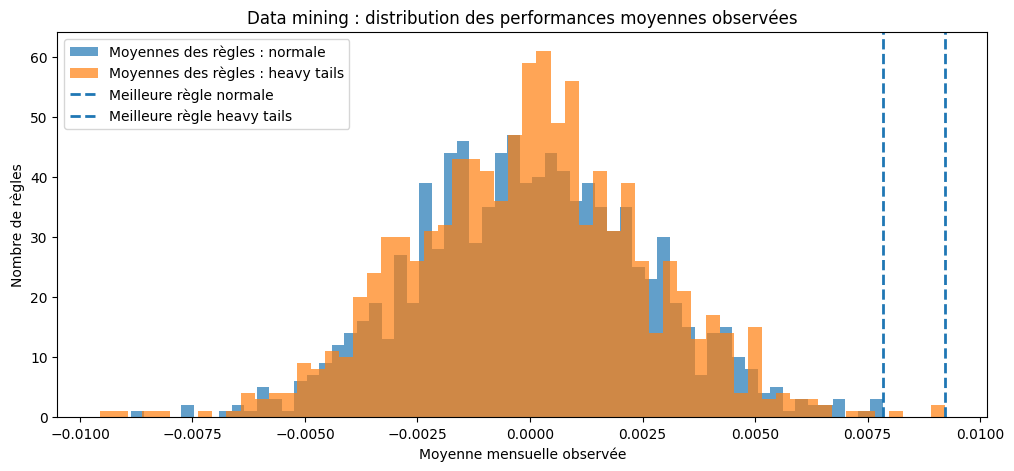

In [5]:
plt.figure(figsize=(12, 5))
plt.hist(normal_mining["mean_returns"], bins=60, alpha=0.7, label="Moyennes des règles : normale")
plt.hist(heavy_mining["mean_returns"], bins=60, alpha=0.7, label="Moyennes des règles : heavy tails")
plt.axvline(normal_mining["best_mean"], linestyle="--", linewidth=2, label="Meilleure règle normale")
plt.axvline(heavy_mining["best_mean"], linestyle="--", linewidth=2, label="Meilleure règle heavy tails")
plt.title("Data mining : distribution des performances moyennes observées")
plt.xlabel("Moyenne mensuelle observée")
plt.ylabel("Nombre de règles")
plt.legend()
plt.show()

## 5. Lecture trading : le faux champion du backtest

Le graphique précédent illustre le piège :

> La règle gagnante n'est pas forcément celle qui possède le plus de mérite. C'est souvent celle qui a eu la meilleure coïncidence avec le bruit.

Dans une distribution à **queues épaisses**, certaines règles vont capturer par hasard un gros mouvement.

Cela peut créer une illusion :

$$
\text{Backtest spectaculaire} \neq \text{Edge robuste}
$$

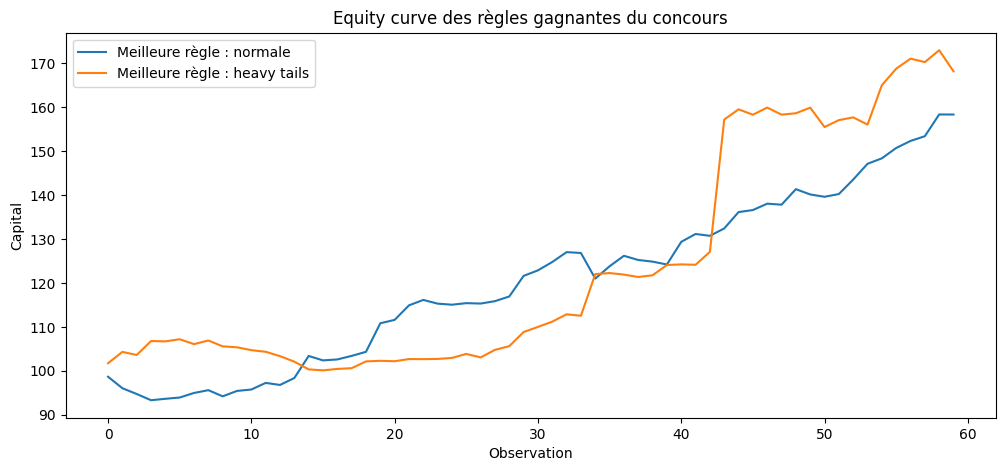

In [6]:
def equity_curve(returns, start=100):
    return start * np.cumprod(1 + returns)

plt.figure(figsize=(12, 5))
plt.plot(equity_curve(normal_mining["best_returns"]), label="Meilleure règle : normale")
plt.plot(equity_curve(heavy_mining["best_returns"]), label="Meilleure règle : heavy tails")
plt.title("Equity curve des règles gagnantes du concours")
plt.xlabel("Observation")
plt.ylabel("Capital")
plt.legend()
plt.show()

## 6. Diagnostic : quelle part du profit vient des meilleurs trades ?

Un test EBTA simple consiste à mesurer la concentration du profit.

Si quelques observations expliquent presque tout le profit, la stratégie est fragile.

Exemple de règle pratique :

| Signal d'alerte | Interprétation |
|---|---|
| $80\%$ du profit vient de $2\%$ des trades | Très forte dépendance aux outliers |
| Profit net positif mais médiane faible | Performance tirée par quelques coups chanceux |
| Ratio moyenne / médiane très élevé | Distribution asymétrique et suspecte |

In [7]:
def profit_concentration(returns, top_fraction=0.02):
    """
    Calcule la part du profit positif total expliquée par les meilleurs rendements.
    """
    positive_returns = returns[returns > 0]

    if len(positive_returns) == 0:
        return np.nan

    n_top = max(1, int(np.ceil(len(positive_returns) * top_fraction)))
    sorted_positive = np.sort(positive_returns)[::-1]

    top_profit = sorted_positive[:n_top].sum()
    total_positive_profit = sorted_positive.sum()

    return top_profit / total_positive_profit


diagnostic = pd.DataFrame({
    "Cas": ["Meilleure règle normale", "Meilleure règle heavy tails"],
    "Moyenne": [normal_mining["best_returns"].mean(), heavy_mining["best_returns"].mean()],
    "Médiane": [np.median(normal_mining["best_returns"]), np.median(heavy_mining["best_returns"])],
    "Max": [normal_mining["best_returns"].max(), heavy_mining["best_returns"].max()],
    "Part du profit positif venant des 2% meilleurs gains": [
        profit_concentration(normal_mining["best_returns"]),
        profit_concentration(heavy_mining["best_returns"])
    ]
})

diagnostic

,Cas,Moyenne,Médiane,Max,Part du profit positif venant des 2% meilleurs gains
0,Meilleure règle normale,0.007839,0.007003,0.062253,0.094523
1,Meilleure règle heavy tails,0.009225,0.002119,0.236906,0.318266


## 7. Remède : couper les queues avec un objectif fixe

Une idée concrète consiste à limiter les gains extrêmes avec un **profit target**.

Cela ne crée pas un edge, mais cela réduit la capacité d'un outlier positif à dominer toute la statistique.

Mathématiquement, on applique un plafonnement :

$$
r_{\text{capped}} = \min(r, \text{target})
$$

Ce plafonnement coupe une partie de la queue positive.

In [8]:
target = 0.05

heavy_best_raw = heavy_mining["best_returns"]
heavy_best_capped = np.minimum(heavy_best_raw, target)

comparison_capped = pd.DataFrame({
    "Cas": ["Original heavy tails", "Avec target fixe à +5%"],
    "Moyenne": [heavy_best_raw.mean(), heavy_best_capped.mean()],
    "Médiane": [np.median(heavy_best_raw), np.median(heavy_best_capped)],
    "Max": [heavy_best_raw.max(), heavy_best_capped.max()],
    "Performance cumulée": [
        (1 + heavy_best_raw).prod() - 1,
        (1 + heavy_best_capped).prod() - 1
    ],
    "Concentration profit top 2%": [
        profit_concentration(heavy_best_raw),
        profit_concentration(heavy_best_capped)
    ]
})

comparison_capped

,Cas,Moyenne,Médiane,Max,Performance cumulée,Concentration profit top 2%
0,Original heavy tails,0.009225,0.002119,0.236906,0.681408,0.318266
1,Avec target fixe à +5%,0.005417,0.002119,0.050000,0.372660,0.096922


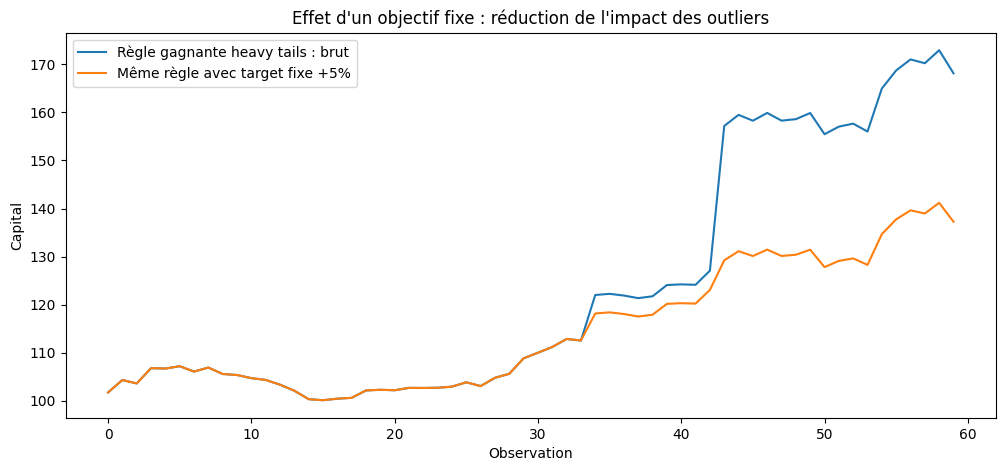

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(equity_curve(heavy_best_raw), label="Règle gagnante heavy tails : brut")
plt.plot(equity_curve(heavy_best_capped), label="Même règle avec target fixe +5%")
plt.title("Effet d'un objectif fixe : réduction de l'impact des outliers")
plt.xlabel("Observation")
plt.ylabel("Capital")
plt.legend()
plt.show()

## 8. Sensibilité à la taille de l'échantillon

L'effet d'un outlier est dilué quand le nombre d'observations augmente.

Pour un outlier fixe :

$$
\Delta \bar{r} = \frac{\text{outlier}}{N}
$$

Donc :

| Nombre d'observations | Effet d'un outlier de $+20\%$ sur la moyenne |
|---:|---:|
| $24$ | $0.83\%$ par observation |
| $60$ | $0.33\%$ par observation |
| $240$ | $0.08\%$ par observation |
| $600$ | $0.03\%$ par observation |

> **Conclusion EBTA :** un grand échantillon ne supprime pas le hasard, mais il réduit la capacité d'un seul événement à raconter une fausse histoire.

In [10]:
sample_sizes = np.array([12, 24, 60, 120, 240, 600, 1200])
outlier = 0.20
impact = outlier / sample_sizes

impact_df = pd.DataFrame({
    "N observations": sample_sizes,
    "Impact sur la moyenne": impact
})

impact_df

,N observations,Impact sur la moyenne
0,12,0.016667
1,24,0.008333
2,60,0.003333
3,120,0.001667
4,240,0.000833
5,600,0.000333
6,1200,0.000167


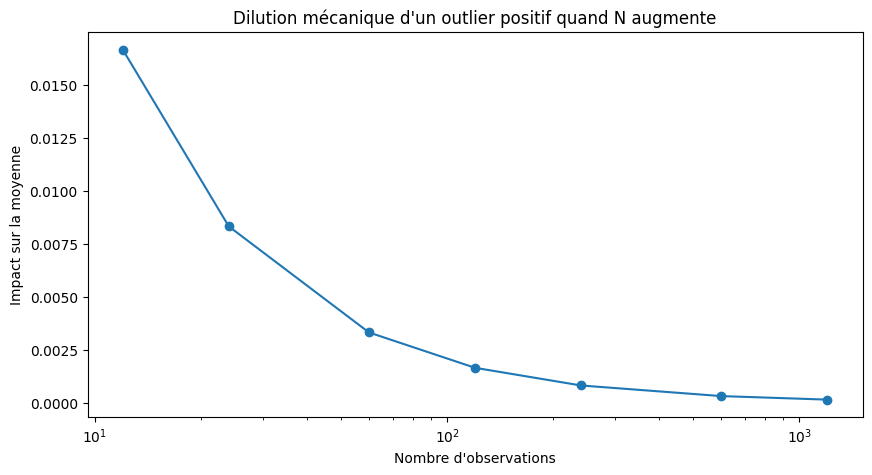

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, impact, marker="o")
plt.title("Dilution mécanique d'un outlier positif quand N augmente")
plt.xlabel("Nombre d'observations")
plt.ylabel("Impact sur la moyenne")
plt.xscale("log")
plt.show()

## 9. Checklist EBTA pour détecter une stratégie contaminée par les outliers

| Question | Danger si la réponse est oui |
|---|---|
| Le backtest dépend-il de 1 à 3 trades énormes ? | Forte probabilité d'illusion statistique |
| La moyenne est-elle beaucoup plus élevée que la médiane ? | Distribution tirée par quelques extrêmes |
| La performance vient-elle surtout d'une crise ou d'un krach ? | Possible coïncidence temporelle |
| Le résultat disparaît-il avec un profit target ? | Edge probablement fragile |
| La stratégie reste-t-elle bonne en retirant les meilleurs trades ? | Test de robustesse indispensable |

## 10. Eurêka final

> **L'Eurêka final :** un outlier positif est comme un projecteur braqué sur une stratégie médiocre. Il ne lui donne pas forcément du mérite, il lui donne seulement de la visibilité dans le concours du backtest.

Le trader EBTA ne demande donc pas seulement :

> "La stratégie a-t-elle gagné ?"

Il demande :

> **"Comment a-t-elle gagné ?"**

Et surtout :

> **"Gagne-t-elle encore si on retire le coup de chance ?"**

## 11. Mini-lab : à toi de modifier les paramètres

Change les paramètres ci-dessous pour observer comment le biais évolue :

| Paramètre | Effet attendu |
|---|---|
| `n_rules` | Plus il augmente, plus le meilleur faux gagnant devient impressionnant |
| `n_obs` | Plus il augmente, plus les outliers sont dilués |
| `df` | Plus il est bas, plus les queues sont épaisses |
| `target` | Plus il est bas, plus les gros coups chanceux sont plafonnés |

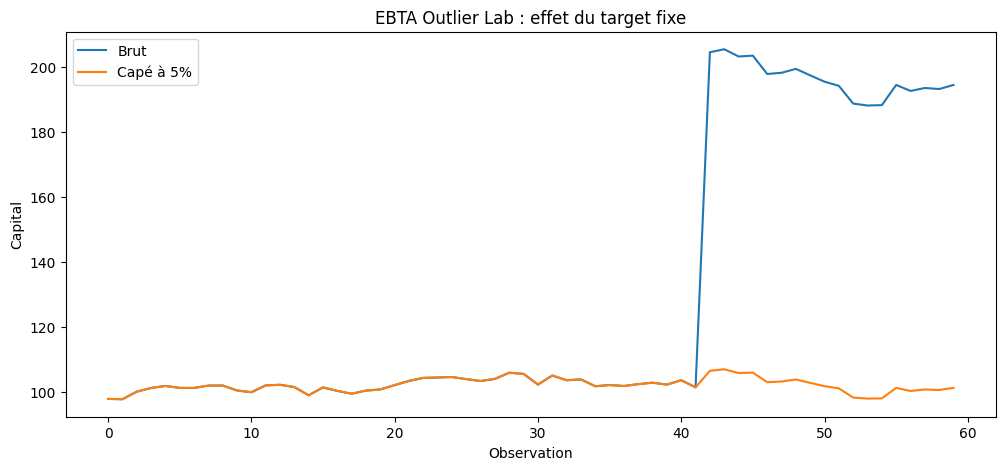

,Mesure,Valeur
0,Meilleure moyenne observée,0.016425
1,Moyenne après target fixe,0.000331
2,Performance cumulée brute,0.945439
3,Performance cumulée capée,0.013414
4,Max brut,1.015673
5,Max capé,0.050000
6,Concentration top 2% brute,0.780300
7,Concentration top 2% capée,0.148822


In [12]:
def ebta_outlier_lab(
    n_rules=2000,
    n_obs=60,
    df=3,
    volatility=0.02,
    target=0.05,
    seed=2026
):
    rng = np.random.default_rng(seed)

    if df <= 2:
        raise ValueError("df doit être supérieur à 2 pour avoir une variance finie.")

    returns = rng.standard_t(df=df, size=(n_rules, n_obs)) * volatility / np.sqrt(df / (df - 2))

    means = returns.mean(axis=1)
    best_idx = np.argmax(means)
    best_returns = returns[best_idx]
    capped_returns = np.minimum(best_returns, target)

    result = pd.DataFrame({
        "Mesure": [
            "Meilleure moyenne observée",
            "Moyenne après target fixe",
            "Performance cumulée brute",
            "Performance cumulée capée",
            "Max brut",
            "Max capé",
            "Concentration top 2% brute",
            "Concentration top 2% capée"
        ],
        "Valeur": [
            best_returns.mean(),
            capped_returns.mean(),
            (1 + best_returns).prod() - 1,
            (1 + capped_returns).prod() - 1,
            best_returns.max(),
            capped_returns.max(),
            profit_concentration(best_returns),
            profit_concentration(capped_returns)
        ]
    })

    plt.figure(figsize=(12, 5))
    plt.plot(equity_curve(best_returns), label="Brut")
    plt.plot(equity_curve(capped_returns), label=f"Capé à {target:.0%}")
    plt.title("EBTA Outlier Lab : effet du target fixe")
    plt.xlabel("Observation")
    plt.ylabel("Capital")
    plt.legend()
    plt.show()

    return result

ebta_outlier_lab()

## Annexe : texte source fourni

### **CH 6 : FACTOR 4 - PRESENCE OF POSITIVE OUTLIERS IN RULE RETURNS**

Cette section analyse comment les rendements extrêmes (outliers) influencent l'ampleur du biais de minage de données, transformant parfois un simple coup de chance temporel en une illusion de stratégie gagnante.

#### **Idées clés :**
*   **Amplification du biais :** La présence de quelques rendements extrêmement positifs dans l'historique d'une règle augmente mécaniquement le biais de minage.
*   **Sensibilité à la taille de l'échantillon :** L'impact d'une valeur aberrante est inversement proportionnel au nombre d'observations ; moins il y a de données, plus l'outlier "gonfle" artificiellement la moyenne.
*   **Le concept de "Queues Épaisses" (Heavy Tails) :** Les marchés financiers ne suivent pas une distribution normale ; les événements extrêmes y sont plus fréquents, ce qui favorise les faux positifs lors du minage.
*   **L'effet de coïncidence :** Une règle peut gagner une compétition de backtest simplement parce qu'elle était positionnée dans le bon sens lors d'un krach ou d'un mouvement extrême.

#### **Référence :**
*Factor 4: Presence of Positive Outliers in Rule Returns*, Chapitre 6, pages 302 à 306.

#### **Citation Directe :**
« A sample of rule returns (daily, weekly, or monthly) that contains a few extremely large positive observations has the potential to create a large data mining bias. » (Page 303).

---

#### **Vision Macro :**
L'enjeu est de distinguer le profit structurel (pouvoir prédictif) du profit accidentel (hasard extrême). David Aronson explique que le minage de données est une machine à chercher des records. Dans un environnement comme le marché boursier, où des mouvements massifs et imprévisibles surviennent, une règle médiocre peut afficher une performance spectaculaire si ses signaux coïncident, par pur hasard, avec ces anomalies. Pour le trader EBTA, un "gros trade" n'est pas une preuve de talent, mais souvent un bruit statistique qui pollue l'estimation du mérite réel.

---

#### **Vision Micro :**

1.  **Mécanisme de distorsion de la moyenne :** La moyenne arithmétique est extrêmement sensible aux valeurs extrêmes. Dans un petit échantillon (ex: 24 mois), un seul mois à +20 % peut faire passer un rendement annuel médiocre pour une performance d'élite.
2.  **Distribution de probabilité (Figure 6.37) :** 
    *   **Light Tails (Queues légères) :** Les observations extrêmes sont quasi inexistantes (ex: la taille humaine). Le risque de biais est faible.
    *   **Heavy Tails (Queues épaisses) :** Les observations extrêmes sont plus fréquentes (ex: rendements boursiers). La distribution s'élargit, offrant au minage de données davantage d'opportunités de trouver un "gagnant" par chance extrême (Figure 6.40).
3.  **Expérimentation avec les ATR :** Aronson a comparé des règles basées sur les rendements réels du S&P 500 (queues épaisses) à des règles basées sur une distribution normale (queues légères).
    *   **Résultat :** Le biais de minage est beaucoup plus prononcé avec les données du S&P 500, confirmant que la nature même des marchés financiers encourage l'apparition de "métal des fous".

---

#### **Résumé Simplifié :**
Un seul "coup de chance" (comme être vendeur juste avant un krach) peut suffire à rendre une stratégie nulle très rentable sur le papier. L'ordinateur, en cherchant la meilleure stratégie, va sauter sur ce coup de chance et vous dire : "C'est celle-là la meilleure !". Mais comme ce gros gain ne se répétera pas, vous serez déçu en trading réel.

---

#### **Actions Concrètes :**
*   **Utiliser des objectifs de profit fixes (Fixed Targets) :** En limitant le gain maximum par trade, vous "coupez" les queues de la distribution, ce qui réduit le biais de minage et rend la performance plus robuste.
*   **Augmenter le nombre d'observations :** Plus l'historique est long, plus l'impact d'un trade chanceux est dilué dans la masse, ramenant la moyenne vers la vérité.
*   **Analyser la décomposition des gains :** Si 80 % du profit de votre backtest provient de 2 % des trades, votre stratégie est probablement une victime du biais de minage lié aux outliers.
*   **Être sceptique face aux "gagnants de krach" :** Si une règle affiche des profits records durant des périodes de volatilité extrême, vérifiez si elle possède une logique solide ou si elle a simplement bénéficié d'une coïncidence temporelle.

---

#### **À retenir absolument :**
*   Les **outliers positifs** sont des usines à créer du biais.
*   Le marché a des **queues épaisses**, ce qui rend le minage plus dangereux que dans d'autres domaines.
*   Un grand échantillon (N élevé) est le seul moyen de **diluer l'effet de la chance**.
*   Les **sorties à objectif fixe** stabilisent les statistiques de performance.
*   Le profit passé dû à un événement rare est un **mauvais prédicteur** du futur.

J'ai terminé l'analyse du facteur 4 (outliers) selon le protocole EBTA.